This code is to visualize the ground truth part masks. There are two ways to visualize it. First way is without using dataset

In [1]:
import os
import yaml
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm
from PIL import Image

# import torch
# from torch.utils.data import Subset, Dataset, DataLoader
from torchvision import transforms

In [2]:
# Hyperparameters and paths
DEVICE_ID = 7
BATCH_SIZE = 128
IMAGE_SIZE = 320

DATA_DIR = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"

train_imgs_path = os.path.join(DATA_DIR, 'train', 'images')
val_imgs_path = os.path.join(DATA_DIR, 'valid', 'images')
test_imgs_path = os.path.join(DATA_DIR, 'test', 'images')
train_images = os.listdir(train_imgs_path)
val_images = os.listdir(val_imgs_path)
test_images = os.listdir(test_imgs_path)
print(f"Images in dataset, train: {len(train_images)}, val: {len(val_images)}, test: {len(test_images)}")

Images in dataset, train: 23903, val: 2812, test: 1407


In [3]:
yaml_path = os.path.join(DATA_DIR, 'data.yaml')
with open(yaml_path, 'r') as file:
    # Use safe_load for security, as it prevents arbitrary code execution
    config = yaml.safe_load(file)
print(config)
labels = config['names']
if 'background' not in labels:
    labels.insert(0, 'background')
print(labels)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['abdomen', 'head', 'thorax']}
['background', 'abdomen', 'head', 'thorax']


In [4]:
# Visualize
def visualize(**images):
    """Plot images + masks in one row with perfect discrete colormap legend (unlimited classes)"""
    n = len(images)
    plt.figure(figsize=(4 + 4 * n, 6))  # auto-scale width
    
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([]), plt.yticks([])
        plt.title(" ".join(name.split("_")).title(), fontsize=14)

        if name == "image":
            # Handle CHW → HWC
            img = np.asarray(image)
            if img.ndim == 3 and img.shape[0] == 3:
                img = img.transpose(1, 2, 0)
            # Normalize to 0-1 if needed
            if img.max() > 1.0:
                img = img / 255.0
            plt.imshow(img)
            continue

        # ———————— MASK PLOTTING (supports unlimited classes) ————————
        mask = np.asarray(image).squeeze()  # HxW
        unique_vals = np.unique(mask)
        
        # Choose a colormap with many distinct colors
        base_cmap = plt.get_cmap("turbo")        # 256 beautiful distinct colors
        # Or: "nipy_spectral", "hsv", "jet", "gist_ncar"

        # Make it fully discrete
        max_val = int(mask.max())
        bounds = np.arange(-0.5, max_val + 1.5, 1)   # one bin per integer class
        norm = BoundaryNorm(bounds, base_cmap.N)        
        plt.imshow(mask, cmap=base_cmap, norm=norm, interpolation='nearest')

        # ———————— LEGEND: exact matching colors ————————
        legend_patches = []
        for val in sorted(unique_vals):
            if val >= len(labels):
                label_name = f"Class {int(val)} (unknown)"
                color = 'lightgray'
            else:
                label_name = labels[int(val)]
                color = base_cmap(norm(val))  # exact color used in image
            
            legend_patches.append(
                Patch(color=color, label=label_name)
            )

        plt.legend(
            handles=legend_patches,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            borderaxespad=0.0,
            fontsize=10,
            title="Classes",
            title_fontsize=12
        )

    plt.tight_layout()
    plt.show()

In [5]:
transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.5016, 0.4647, 0.3782], std=[0.2738, 0.2654, 0.2885]) # Computed using the find_mean_and_sd_of_partwhole_dataset script
        ])

original image size: (243, 230) mask shape: (243, 230) class_ids: [0 1 2 3]


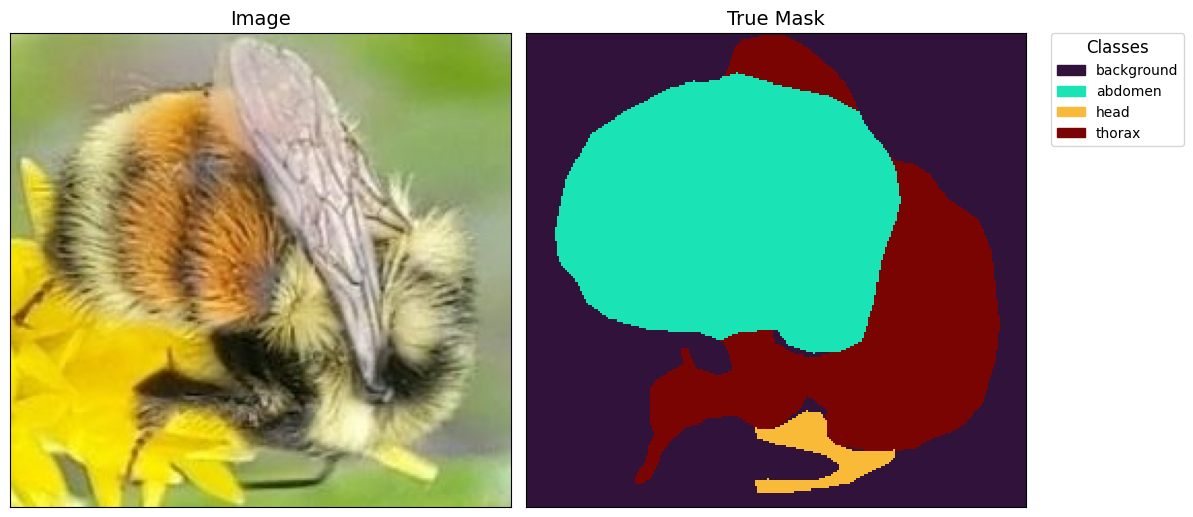

In [6]:
# Get a sample image
sample_image = val_images[0]
sample_img_path = os.path.join(val_imgs_path, sample_image)
sample_pil = Image.open(sample_img_path)
sample_img_tensor = transform(sample_pil).to(f"cuda:{DEVICE_ID}")
# plt.imshow(sample_pil)

# True mask
base = os.path.splitext(sample_image)[0]
mask_path = os.path.join(DATA_DIR, 'valid', 'masks', base + "_m.png")
true_mask = Image.open(mask_path).convert("L")

# Print outputs
print(f'original image size: {sample_pil.size}','mask shape:', true_mask.size, 'class_ids:', np.unique(true_mask))
visualize(image=sample_pil, true_mask=true_mask)

Second way to visualize sample from dataset.

In [7]:
import torch
from torch.utils.data import DataLoader, Dataset

In [8]:
class PartWholeDataset(Dataset):
    def __init__(self, root, images_dir="images", masks_dir="masks", image_size=320):
        self.images_dir = os.path.join(root, images_dir)
        self.masks_dir = os.path.join(root, masks_dir)
        self.image_paths = sorted([os.path.join(self.images_dir, f) for f in os.listdir(self.images_dir)])
        self.image_size = image_size

        # transform for image
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.5016, 0.4647, 0.3782], std=[0.2738, 0.2654, 0.2885]) # Computed using the find_mean_and_sd_of_partwhole_dataset script
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        base = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(self.masks_dir, base + "_m.png")

        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)
        mask = Image.open(mask_path).convert("L")
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)
        mask = torch.from_numpy(np.array(mask, dtype=np.int64))
        return img, mask, img_path

In [9]:
# Load the datasets
home_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v1/"
train_path = os.path.join(home_path, "train") # Path for the training data
val_path = os.path.join(home_path, "valid") # Path for validation data
test_path = os.path.join(home_path, "test") # Path for testing data

train_dataset = PartWholeDataset(root=train_path, image_size=IMAGE_SIZE)
val_dataset = PartWholeDataset(root=val_path, image_size=IMAGE_SIZE)
test_dataset = PartWholeDataset(root=test_path, image_size=IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Images in dataset, train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

Images in dataset, train: 23903, val: 2812, test: 1407


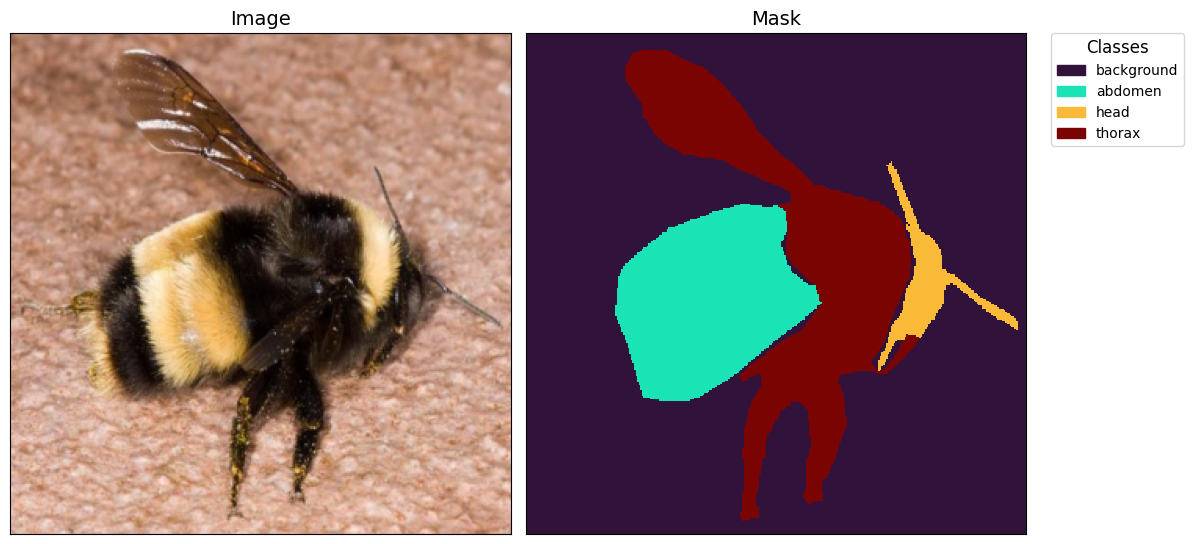

In [10]:
# Get sample image and mask
img, mask, _ = train_dataset[8]
visualize(image=img, mask=mask)